In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import KBinsDiscretizer

In [47]:
df=pd.read_csv('train.csv',usecols=['Survived','Age','Fare'])
df.shape

(891, 3)

In [48]:
df.dropna(inplace=True)

In [45]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [50]:
df.shape

(714, 3)

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
x_train.head()

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750


In [22]:
clf=DecisionTreeClassifier()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

In [25]:
accuracy_score(y_test,y_pred)

0.659217877094972

In [27]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

0.6599750312109862

In [28]:
kbin_age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [31]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
]
)

In [52]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

In [58]:
trf.named_transformers_['first'].n_bins_

array([10])

In [59]:
trf.named_transformers_['second'].bin_edges_


array([array([  0.    ,   7.75  ,   7.8958,   9.225 ,  13.    ,  15.75  ,
               26.    ,  29.125 ,  51.4792,  82.1708, 512.3292])         ],
      dtype=object)

In [66]:
output=pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:,1]
})

In [67]:
output.sample(5)

,age,age_trf,fare,fare_trf
38,18.0,1.0,18.0000,5.0
622,20.0,2.0,15.7417,4.0
856,45.0,8.0,164.8667,9.0
376,22.0,3.0,7.2500,0.0
242,29.0,5.0,10.5000,3.0


In [69]:
clf=DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2=clf.predict(x_test_trf)

In [70]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

In [72]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

0.6288928012519561

0.6205203442879499


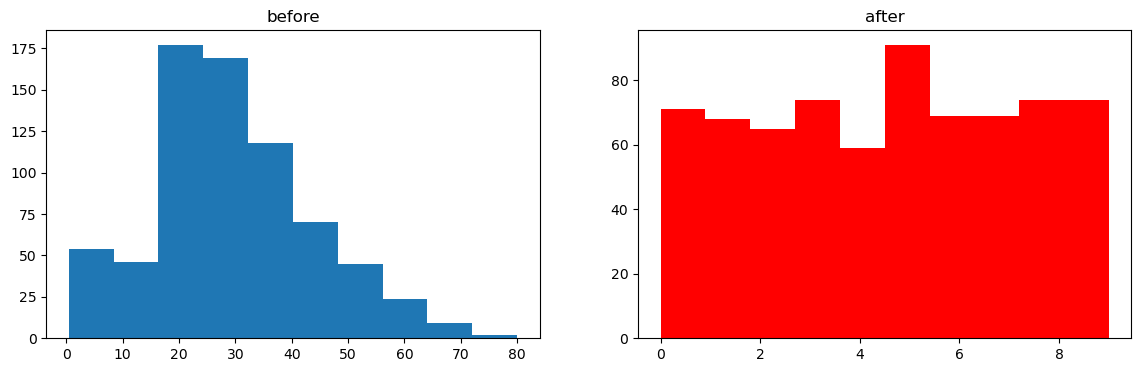

In [96]:
def discretize(bins,strategy):
    kbin_age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
]
)
x_trf=trf.fit_transform(x)
print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(x['Age'])
plt.title('before')

plt.subplot(122)
plt.hist(x_trf[:,0],color='red')
plt.title('after')
plt.show()



In [95]:
discretize(10,'uniform')